In [7]:
from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from operator import add

In [2]:
load_dotenv()

True

In [25]:
class EvaluationSchema(BaseModel):

    feedback: str = Field(description="Detailed feedback of the provided essay")
    score: float =Field(description = "Score of a provided essay out of 10.", ge=0,le=10)

In [26]:
model = ChatGroq(model="openai/gpt-oss-120b")

structured_model = model.with_structured_output(EvaluationSchema)

In [27]:
class EssayEvaluation(TypedDict):

    essay: str
    cot_feedback: str
    doa_feedback: str
    language_feedback: str

    overall_feedback: str
    individual_scores: Annotated[list[float], add]
    avg_score: float

In [36]:
def cot_feedback(state: EssayEvaluation):

    essay = state['essay']

    prompt = f"Evaluate a clarity of thoughts and provide a detailed feedback and score for \n {essay}"

    output = structured_model.invoke(prompt)

    return {'cot_feedback': output.feedback, 'individual_scores': [output.score]}

In [37]:
def doa_feedback(state: EssayEvaluation):

    prompt = f"Evaluate a depth of analysis and provide a detailed feedback and score for \n {state['essay']}"

    output = structured_model.invoke(prompt)

    return {
        'doa_feedback': output.feedback,
        'individual_scores': [output.score]
    }

In [38]:
def language_feedback(state: EssayEvaluation):

    prompt = f"Evaluate a language and provide a detailed feedback and score for \n {state['essay']}"

    output = structured_model.invoke(prompt)

    return {
        'language_feedback': output.feedback,
        'individual_scores': [output.score]
    }

In [39]:
def summary(state: EssayEvaluation):

    prompt = f"Based on the provided feedbacks provide a summarised feedback \n clarity of thought -> {state['cot_feedback']} \n depth of analysis -> {state['doa_feedback']} \n language feedback -> {state['language_feedback']}"

    output = model.invoke(prompt).content

    avg_feedback = sum(state['individual_scores'])/len(state['individual_scores'])

    return {
        'overall_feedback': output,
        'avg_score': avg_feedback
    }

In [40]:
# create a graph
graph = StateGraph(EssayEvaluation)

# add nodes

graph.add_node('cot_feedback', cot_feedback)
graph.add_node('doa_feedback', doa_feedback)
graph.add_node('language_feedback', language_feedback)
graph.add_node("summary", summary)

# add edges
graph.add_edge(START, 'cot_feedback')
graph.add_edge(START, 'doa_feedback')
graph.add_edge(START, 'language_feedback')

graph.add_edge('cot_feedback','summary')
graph.add_edge('doa_feedback', 'summary')
graph.add_edge('language_feedback', 'summary')

graph.add_edge('summary', END)

# compile the graph
workflow = graph.compile()

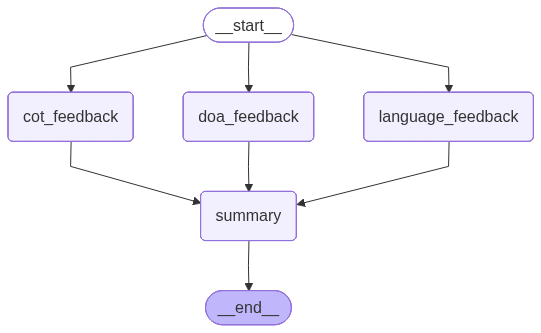

In [41]:
workflow

In [42]:
essay = """
Technology has transformed the way people live, work, and communicate. From smartphones to artificial intelligence, modern innovations have made daily tasks faster and more convenient. Students can learn online, businesses can connect globally, and doctors can provide better healthcare with advanced tools.

However, technology also brings challenges. Excessive use of social media can reduce real-life interaction, and dependence on machines may affect creativity and critical thinking. Privacy and cybersecurity have also become major concerns in the digital age.

Despite these challenges, technology continues to improve human life when used responsibly. The key is to maintain a balance between digital convenience and healthy human values. When guided properly, technology can become a powerful tool for progress and innovation.

"""

In [43]:
initial_state = {'essay': essay}

workflow.invoke(initial_state)

{'essay': '\nTechnology has transformed the way people live, work, and communicate. From smartphones to artificial intelligence, modern innovations have made daily tasks faster and more convenient. Students can learn online, businesses can connect globally, and doctors can provide better healthcare with advanced tools.\n\nHowever, technology also brings challenges. Excessive use of social media can reduce real-life interaction, and dependence on machines may affect creativity and critical thinking. Privacy and cybersecurity have also become major concerns in the digital age.\n\nDespite these challenges, technology continues to improve human life when used responsibly. The key is to maintain a balance between digital convenience and healthy human values. When guided properly, technology can become a powerful tool for progress and innovation.\n\n',
 'cot_feedback': "The essay presents a clear and coherent argument about the dual nature of technology, offering a balanced perspective that 

In [44]:
essay2 = """
Technology is very important in our daily life and peoples are using it everydays. Many student use mobile phones for studying but sometime they wasting too much times on social media. The internet have changed the way how we communicate with each other and it make work more easier.

There is also many disadvantages of technology. Some peoples become addicted to games and they dont talk with family properly. Privacy problems is also increasing because many apps collect personal informations without permission. In some cases, technology also reduce physical activities which causing health issue.

In conclusion, technology is useful but it should be use carefully. If peoples use technology in a balanced way then it can help society grow and improve future for everyone.

"""

In [45]:
initial_state = {'essay': essay2}

workflow.invoke(initial_state)

{'essay': '\nTechnology is very important in our daily life and peoples are using it everydays. Many student use mobile phones for studying but sometime they wasting too much times on social media. The internet have changed the way how we communicate with each other and it make work more easier.\n\nThere is also many disadvantages of technology. Some peoples become addicted to games and they dont talk with family properly. Privacy problems is also increasing because many apps collect personal informations without permission. In some cases, technology also reduce physical activities which causing health issue.\n\nIn conclusion, technology is useful but it should be use carefully. If peoples use technology in a balanced way then it can help society grow and improve future for everyone.\n\n',
 'cot_feedback': 'The essay attempts to discuss both the benefits and drawbacks of technology, but the clarity of thought is hampered by several issues:\n\n1. **Organization and Structure** – The ess